In [1]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu 

In [2]:
import constants as c
import helpers as h 
h.latex(True)

2025-12-01 11:54:52 - analysis-helpers - INFO - Enabling LaTeX for matplotlib.


In [3]:
d = pd.read_csv(c.CURRENT_NO_COVARIATES_DF)
d = h.add_covariate_cols(d)
d = h.add_estimate_cols(d)

EST_TO_USE = c.ESTIMATE_TO_USE 


2025-12-01 11:54:52 - analysis-helpers - INFO - Found 192 tracts with at least one FloodNet sensor.
2025-12-01 11:54:52 - analysis-helpers - INFO - Found 2171 311 requests.
2025-12-01 11:54:52 - analysis-helpers - INFO - Found 878 tracts with at least one 311 report.
2025-12-01 11:54:52 - analysis-helpers - INFO - Found 1001 tracts with no DEP flooding.
2025-12-01 11:54:52 - analysis-helpers - INFO - Found 168 tracts with confirmed flooding.
2025-12-01 11:54:52 - analysis-helpers - INFO - Found 254 tracts with above threshold (0.0060349044628558) flooding.
2025-12-01 11:54:52 - analysis-helpers - INFO - Found 296 tracts with confirmed or above threshold flooding.


In [ ]:
d = d[['p_y', EST_TO_USE, 'any_311_report', 'any_sensors',
       'ft_elevation_min', 'ft_elevation_mean', 'ft_elevation_max', 'dep_moderate_1_frac', 'dep_moderate_2_frac',
       'n_catch_basins', 'catch_basin_density', 'cb_days_clogged', 'cb_avg_resolution_time', 'has_clogged_cb_complaint']]



In [ ]:
row_mapping = {
    'any_311_report': 'Any 311 Report in tract?',
    'n_311_reports': '\# of 311 Reports in tract',
    'any_sensors': 'Any FloodNet sensors in tract?',
    'n_floodnet_sensors': '\# of FloodNet sensors in tract',
    'dep_moderate_1_frac': r'Frac. DEP Shallow Flooding [${ft}^2$]',
    'dep_moderate_2_frac': r'Frac. DEP Deep Flooding [${ft}^2$]',
    'ft_elevation_min': 'Minimum elevation in tract [ft]',
    'ft_elevation_mean': 'Mean elevation in tract [ft]',
    'ft_elevation_max': 'Maximum elevation in tract [ft]',
    'n_catch_basins': '\# of Catch Basins in tract',
    'catch_basin_density': r'Catch Basin Density [basins/${ft}^2$]',
    'cb_days_clogged': 'Catch Basin Days Clogged (Jun-Sep 2023)',
    'cb_avg_resolution_time': 'Avg. Catch Basin Resolution Time [days]',
    'has_clogged_cb_complaint': 'Any Clogged CB Complaint (Jun-Sep 2023)?'
}

<>:3: SyntaxWarning: invalid escape sequence '\#'
<>:5: SyntaxWarning: invalid escape sequence '\#'
<>:11: SyntaxWarning: invalid escape sequence '\#'
<>:3: SyntaxWarning: invalid escape sequence '\#'
<>:5: SyntaxWarning: invalid escape sequence '\#'
<>:11: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_3981800/784036656.py:3: SyntaxWarning: invalid escape sequence '\#'
  'n_311_reports': '\# of 311 Reports in tract',
/tmp/ipykernel_3981800/784036656.py:5: SyntaxWarning: invalid escape sequence '\#'
  'n_floodnet_sensors': '\# of FloodNet sensors in tract',
/tmp/ipykernel_3981800/784036656.py:11: SyntaxWarning: invalid escape sequence '\#'
  'n_catch_basins': '\# of Catch Basins in tract',


any_311_report 1.2563925111094925
any_sensors 1.747284048754637
ft_elevation_min 0.5430727044853157
ft_elevation_mean 0.6975070778086744
ft_elevation_max 0.8767871901686353
dep_moderate_1_frac 1.4678103317781885
dep_moderate_2_frac 1.4431221251399902
n_catch_basins 1.088696062621395
catch_basin_density 0.8043662434659055
cb_days_clogged 0.9829620022146578


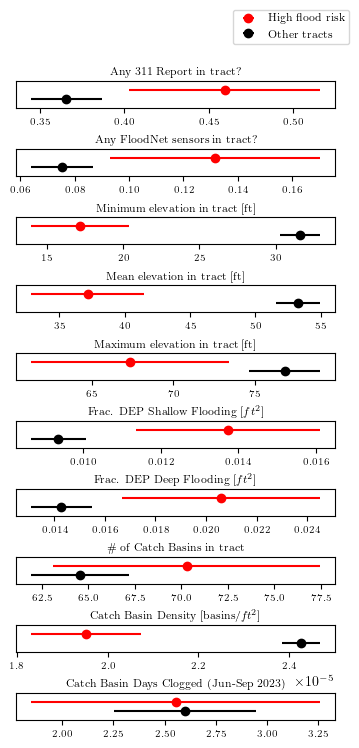

In [ ]:
d['high_flood_risk'] = d[EST_TO_USE]
# drop EST_TO_USE 
d = d.drop(EST_TO_USE, axis=1)
plot_num = 0
fig = plt.figure(figsize=[4, 8])

legend_handles = []
legend_labels = []

for k in d.columns:
    if 'p_y' not in k and 'high_flood_risk' not in k:
        plot_num += 1
        ax = plt.subplot(12, 1, plot_num)
        means_by_bin = d.groupby('high_flood_risk')[k].mean()
        stds_by_bin = d.groupby('high_flood_risk')[k].std()
        bin_sizes = d.groupby('high_flood_risk').size()
        assert list(means_by_bin.index) == [0, 1]
        
        # print the ratio of the means for each feature
        print(k, means_by_bin.iloc[1] / means_by_bin.iloc[0])
        
        if plot_num == 1:
            high_risk = plt.errorbar(means_by_bin.iloc[1],
                            0.75, 
                            xerr=1.96 * stds_by_bin.iloc[1] / (bin_sizes.iloc[1]**0.5), 
                            color='red', 
                            fmt='o', 
                            label='High flood risk')
            other_tracts = plt.errorbar(means_by_bin.iloc[0], 
                            0.25, 
                            xerr=1.96 * stds_by_bin.iloc[0] / (bin_sizes.iloc[0]**0.5), 
                            color='black', 
                            fmt='o', 
                            label='Other tracts')
            legend_handles = [high_risk, other_tracts]
            legend_labels = ['High flood risk', 'Other tracts']
        else:
            plt.errorbar(means_by_bin.iloc[1],
                        0.75, 
                        xerr=1.96 * stds_by_bin.iloc[1] / (bin_sizes.iloc[1]**0.5), 
                        color='red', 
                        fmt='o')
            plt.errorbar(means_by_bin.iloc[0], 
                        0.25, 
                        xerr=1.96 * stds_by_bin.iloc[0] / (bin_sizes.iloc[0]**0.5), 
                        color='black', 
                        fmt='o')

        p_val = mannwhitneyu(d.loc[d['high_flood_risk'] == 1, k], 
                             d.loc[d['high_flood_risk'] == 0, k])[1]
        plt.ylim([-0.25, 1.25])

        
       
        
        plt.title(row_mapping[k], fontsize=8, pad=4)
        
        # Add p-value with stars to the right side
        stars = ''
        if p_val < 0.001:
            stars = '***'
        elif p_val < 0.01:
            stars = '**'
        elif p_val < 0.05:
            stars = '*'
            
        #ax.text(1.02, 1.2, f'p = {p_val:.1e}{stars}', 
        #        transform=ax.transAxes,
        #        fontsize=8,
        #        horizontalalignment='right',
        #        verticalalignment='center')
        
        plt.yticks([])
        # set x ticks font size 
        plt.xticks(fontsize=7)

plt.tight_layout()

fig.legend(legend_handles, legend_labels, 
          loc='upper right', 
          bbox_to_anchor=(0.9, 1.07), fontsize=8)

plt.subplots_adjust(right=0.85, hspace=1.5)

plt.savefig(f'{c.PAPER_PATH}/figures/external_corrs_vs_risk.pdf', dpi=200, bbox_inches='tight', pad_inches=0.025)

In [7]:
# what is the pearson between high flood risk and each of the features?
for k in d.columns:
    if 'p_y' not in k and 'high_flood_risk' not in k:
        print(k, spearmanr(d['high_flood_risk'], d[k]))
        print(k, pearsonr(d['high_flood_risk'], d[k]))

any_311_report SignificanceResult(statistic=np.float64(0.06446627101730255), pvalue=np.float64(0.00187078056667377))
any_311_report PearsonRResult(statistic=np.float64(0.06446627101730258), pvalue=np.float64(0.0018707805666737872))
any_sensors SignificanceResult(statistic=np.float64(0.06823951520751369), pvalue=np.float64(0.0009931534288933773))
any_sensors PearsonRResult(statistic=np.float64(0.06823951520751362), pvalue=np.float64(0.000993153428893378))
ft_elevation_min SignificanceResult(statistic=np.float64(-0.22100383004852978), pvalue=np.float64(4.083263513226754e-27))
ft_elevation_min PearsonRResult(statistic=np.float64(-0.15585060818185226), pvalue=np.float64(4.123993694037523e-14))
ft_elevation_mean SignificanceResult(statistic=np.float64(-0.18526981139616697), pvalue=np.float64(2.1242349268958033e-19))
ft_elevation_mean PearsonRResult(statistic=np.float64(-0.13611069741319218), pvalue=np.float64(4.392904462862568e-11))
ft_elevation_max SignificanceResult(statistic=np.float64(-